# CH17A Predicting Firm Fast Growth

Using the bisnode-firms dataset

In [21]:
import os
import sys
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import patsy
import sklearn.metrics as metrics
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings("ignore")

In [22]:
# Current script folder
path = os.getcwd()

# Set the location of data directory
data_in = os.path.join("..", "data")
data_out = os.path.join("..", "data")

## Import data

In [23]:
# !!! make sure you have run ch17-firm-exit-data-prep.ipynb before
data = pd.read_csv(os.path.join(data_out, "bisnode_firms_clean.csv"))

In [24]:
data.describe()

,year,comp_id,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,inc_bef_tax,...,share_eq_bs_quad,asset_tangibility,liquidity_ratio,roa,labor_intensity,leverage,ln_total_assets,young_high_roa,d1_sales_mil_log_mod,sales_mil_log_sq
count,19996.0,1.999600e+04,1.995800e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,...,19996.000000,19996.000000,19647.000000,19996.000000,19958.000000,19996.000000,19996.000000,19996.000000,19996.0,1.999600e+04
mean,2012.0,1.535275e+11,9.613279e+03,1.055301e+05,9.020418e+04,1.304783e+03,2.512944e+03,1.204834e+03,1.585579e+05,7.234908e+03,...,0.479465,0.335533,2.327006,-0.156458,0.299289,0.658384,10.246006,0.089518,0.0,1.221355e+01
std,0.0,1.379137e+11,5.091653e+04,4.771275e+05,5.282025e+05,1.207577e+05,1.251575e+05,3.193274e+04,1.204779e+06,1.290689e+05,...,0.389209,0.340594,2.962580,0.456299,0.245390,0.351076,2.076218,0.285497,0.0,1.047088e+01
min,2012.0,1.001541e+06,-1.489630e+04,0.000000e+00,-8.759259e+03,-1.418519e+03,-1.740741e+02,-2.888889e+05,0.000000e+00,-1.091879e+07,...,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,1.309333,0.000000,0.0,2.074996e-07
25%,2012.0,2.906338e+10,1.481481e+02,3.574074e+03,3.554630e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.333333e+02,-5.762963e+03,...,0.086440,0.008395,0.340705,-0.349432,0.125657,0.339740,8.893598,0.000000,0.0,4.002632e+00
50%,2012.0,1.141679e+11,9.666667e+02,1.202222e+04,1.416852e+04,0.000000e+00,0.000000e+00,0.000000e+00,5.150000e+03,3.259259e+02,...,0.413706,0.213921,1.113087,0.002807,0.250465,0.765821,10.173515,0.000000,0.0,9.625974e+00
75%,2012.0,2.581020e+11,4.214815e+03,4.143796e+04,4.769074e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.241018e+04,4.340741e+03,...,0.943454,0.625892,2.779364,0.068201,0.408589,1.000000,11.538431,0.000000,0.0,1.744029e+01
max,2012.0,4.641050e+11,3.570863e+06,2.066350e+07,4.186429e+07,1.704172e+07,1.709232e+07,3.253704e+06,1.036673e+08,4.378226e+06,...,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,18.466450,1.000000,0.0,4.771708e+01


In [25]:
# Quick data overview
print(f"Dataset shape: {data.shape}")
print(f"\nFast growth distribution:")
print(data['fast_growth'].value_counts(dropna=False))
print(f"\nFast growth rate: {data['fast_growth'].mean():.2%}")

Dataset shape: (19996, 118)

Fast growth distribution:
fast_growth
0.0    14226
1.0     5770
Name: count, dtype: int64

Fast growth rate: 28.86%


## Define helper functions

In [26]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance = metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    median_absolute_error = metrics.median_absolute_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)

    print("explained_variance: ", round(explained_variance, 4))
    print("r2: ", round(r2, 4))
    print("MAE: ", round(mean_absolute_error, 4))
    print("MSE: ", round(mse, 4))
    print("RMSE: ", round(np.sqrt(mse), 4))


def coef_matrix(X, model):

    coef_matrix = pd.concat(
        [pd.DataFrame(X.columns), pd.DataFrame(np.transpose(model.coef_))], axis=1
    )
    coef_matrix.columns = ["variable", "coefficient"]
    coef_matrix = coef_matrix.append(
        {"variable": "Intercept", "coefficient": model.intercept_},
        ignore_index=True,
    )
    return coef_matrix


def cv_fast_growth(lambdas, C_values, model):
    d = {
        "lambdas": lambdas,
        "C_values": C_values,
        "mean_cv_score": model.scores_[1].mean(axis=0),
    }
    return pd.DataFrame(data=d)


def sigmoid_array(x):
    return 1 / (1 + np.exp(-x))


def generate_fold_prediction(model, X, fold, param_index):
    fold_coef = model.coefs_paths_[1][fold, param_index, :]
    return sigmoid_array(
        np.dot(X, np.transpose(fold_coef)[:-1]) + np.transpose(fold_coef)[-1]
    )


def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy["loss"] = (
        all_coords_copy.false_pos * FP + all_coords_copy.false_neg * FN
    ) / all_coords_copy.n

    t = optimal_threshold
    l = curr_exp_loss

    # Plot loss curve
    sns.lineplot(x=all_coords_copy["thresholds"], y=all_coords_copy["loss"])

    # Vertical line for optimal threshold
    plt.axvline(x=t, linestyle="--")

    # Annotations
    plt.text(
        t - 0.03,
        all_coords_copy["loss"].max() - 0.7,
        f"Best threshold: {round(t, 2)}",
        color="red",
        rotation=90,
        fontsize=8,
    )
    plt.text(t + 0.06, l, f"{round(l, 2)}", fontsize=8)

    # Labels and limits
    plt.xlabel("Thresholds")
    plt.ylabel("Expected loss")
    plt.xlim(-0.01, 1.01)
    plt.xticks(np.arange(0, 1.1, 0.1))

    # Style
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()


def create_roc_plot(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)

    # Plot ROC curve
    sns.lineplot(x=fpr, y=tpr, linewidth=1)

    # Fill area under curve
    plt.fill_between(fpr, tpr, alpha=0.3, color="mediumaquamarine")

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="dotted", color="black", linewidth=0.9)

    # Labels and limits
    plt.xlabel("False Positive Rate (1-Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Style
    sns.despine()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()


def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy["sp"] = 1 - all_coords_copy.true_neg / all_coords_copy.neg
    all_coords_copy["se"] = all_coords_copy.true_pos / all_coords_copy.pos

    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    # Plot ROC curve
    sns.lineplot(x=all_coords_copy["sp"], y=all_coords_copy["se"])

    # Highlight optimal threshold point
    plt.scatter(sp, se, color="black", s=10)
    plt.text(sp, se + 0.03, f"{round(sp, 2)}, {round(se, 2)}", fontsize=10, ha="center")

    # Fill area under curve
    plt.fill_between(
        all_coords_copy["sp"],
        all_coords_copy["se"],
        alpha=0.3,
        color="mediumaquamarine",
    )

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="dotted", color="black", linewidth=0.9)

    # Labels and limits
    plt.xlabel("False Positive Rate (1-Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.xlim(0, 1.01)
    plt.ylim(0, 1.01)
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Style
    sns.despine()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()


def create_calibration_plot(data, prob_var, actual_var, y_lab="Actual event probability", n_bins=10, breaks=None):
    # Extract actual values and predicted probabilities, dropping any NaNs
    valid_data = data[[actual_var, prob_var]].dropna()
    y_true = valid_data[actual_var]
    y_prob = valid_data[prob_var]

    # Compute calibration points using sklearn
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Draw diagonal line (perfect calibration)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    
    # Draw the model's calibration curve
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
    
    plt.xlabel('Predicted event probability')
    plt.ylabel(y_lab)
    plt.title('Calibration Plot')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

## Model building

### Define variable sets

Main firm variables

In [27]:
# Main firm variables
rawvars = [
    "curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss",
    "fixed_assets", "inc_bef_tax", "intang_assets", "inventories", "liq_assets",
    "material_exp", "personnel_exp", "profit_loss_year", "sales", "share_eq", "subscribed_cap"
]

Further financial variables

In [28]:
qualityvars = ["balsheet_notfullyear"]
engvar = [
    "liq_assets_bs",
    "curr_assets_bs",
    "subscribed_cap_bs",
    "intang_assets_bs",     
    "extra_exp_pl",
    "extra_inc_pl",
    "extra_profit_loss_pl",
    "inc_bef_tax_pl",
    "inventories_pl",
    "material_exp_pl",
    "profit_loss_year_pl",
    "personnel_exp_pl",
]
engvar2 = [
    "extra_profit_loss_pl_quad",
    "inc_bef_tax_pl_quad",
    "profit_loss_year_pl_quad"
]
engvar3 = [
    "extra_exp_pl_flag_high", "extra_exp_pl_flag_error",
    "extra_inc_pl_flag_high", "extra_inc_pl_flag_error",
    "inventories_pl_flag_high", "inventories_pl_flag_error",
    "material_exp_pl_flag_high", "material_exp_pl_flag_error",
    "personnel_exp_pl_flag_high", "personnel_exp_pl_flag_error",
    "curr_liab_bs_flag_high", "curr_liab_bs_flag_error",
    "liq_assets_bs_flag_high", "liq_assets_bs_flag_error",
    "subscribed_cap_bs_flag_high", "subscribed_cap_bs_flag_error",
    "extra_profit_loss_pl_flag_low", "extra_profit_loss_pl_flag_high", "extra_profit_loss_pl_flag_zero",
    "inc_bef_tax_pl_flag_low", "inc_bef_tax_pl_flag_high", "inc_bef_tax_pl_flag_zero",
    "profit_loss_year_pl_flag_low", "profit_loss_year_pl_flag_high", "profit_loss_year_pl_flag_zero",
    "share_eq_bs_flag_low", "share_eq_bs_flag_high", "share_eq_bs_flag_zero"
]

Growth variables

In [29]:
d1 = [
    "d1_sales_mil_log_mod",
]

Human capital related variables

In [30]:
hr = [
    "gender_m",
    "foreign_management",
    "age",
    "age2",
    "new",
    "ind2_cat",
    "m_region_loc", 
]

Growth Features

In [31]:
growth_features = [
    "asset_tangibility",
    "liquidity_ratio",
    "roa",
    "leverage",
    "ln_total_assets",
    "young_high_roa" 
]

#### Interactions for logit, LASSO

In [32]:
interactions1 = [
    "C(ind2_cat)*age",
    "C(ind2_cat)*age2",
    "C(ind2_cat)*d1_sales_mil_log_mod",
    "C(ind2_cat)*sales_mil_log",
    "C(ind2_cat)*foreign_management",
    "C(ind2_cat)*gender_m",   
]

interactions2 = [
    "sales_mil_log*age",
    "sales_mil_log*gender_m",
    "sales_mil_log*profit_loss_year_pl",
    "sales_mil_log*foreign_management",
]

## Model setups

1. Simple logit models

In [33]:
M1 = [
    "sales_mil_log",
    "d1_sales_mil_log_mod",
    "profit_loss_year_pl"
]
M2 = [
    "sales_mil_log",
    "d1_sales_mil_log_mod",
    "profit_loss_year_pl",
    "fixed_assets_bs",
    "curr_liab_bs",
    "curr_liab_bs_flag_error",
    "age",
    "foreign_management"
]
M3 = ["sales_mil_log"] + engvar + d1 + hr + growth_features
M4 = (
    ["sales_mil_log"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + hr
    + growth_features
    + qualityvars
)
M5 = (
    M4
    + interactions1
    + interactions2
)

2. Logit + LASSO

In [34]:
logit_lasso_vars = (
    ["sales_mil_log", "sales_mil_log_sq"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + hr               # including firm features like age, ind2_cat, region 
    + growth_features  # including growth features like roa, liquidity_ratio
    + qualityvars
    + interactions1
    + interactions2
)

3. CART and RF (no interactions, no modified features)

In [35]:
rfvars = ["sales_mil", "d1_sales_mil_log_mod"] + rawvars + hr + growth_features + qualityvars

---
# PART I: Probability Prediction

We build three models to predict the probability of fast growth:
1. **Logit Model** (5 specifications: M1–M5)
2. **LASSO Logit** 
3. **Random Forest** 

We evaluate each using 5-fold cross-validation and compare performance using RMSE and computational time.

## 0. Separate train and holdout data

In [36]:
# Remove observations with missing fast_growth (our target variable)
data = data[data['fast_growth'].notna()].copy()
print(f"Modeling dataset: {data.shape[0]} observations")

# Create train-test split (80-20)
data_train, data_holdout = train_test_split(data, train_size=0.8, random_state=42)

Modeling dataset: 19996 observations


In [37]:
print("Total")
print(data["fast_growth"].value_counts(normalize=True))
print("Train")
print(data_train["fast_growth"].value_counts(normalize=True))
print("Holdout")
print(data_holdout["fast_growth"].value_counts(normalize=True))

Total
fast_growth
0.0    0.711442
1.0    0.288558
Name: proportion, dtype: float64
Train
fast_growth
0.0    0.710803
1.0    0.289197
Name: proportion, dtype: float64
Holdout
fast_growth
0.0    0.714
1.0    0.286
Name: proportion, dtype: float64


In [38]:
# Filter variable lists to only include columns present in the data
available_cols = data_train.columns.tolist()

def filter_vars(var_list):
    return [v for v in var_list if v in available_cols or v.startswith("C(")]

engvar3 = filter_vars(engvar3)

# Rebuild M4 and M5 with filtered vars
M4 = (
    ["sales_mil_log"]
    + filter_vars(engvar)
    + filter_vars(engvar2)
    + engvar3
    + filter_vars(d1)
    + filter_vars(hr)
    + filter_vars(growth_features)
    + filter_vars(qualityvars)
)
M5 = M4 + interactions1 + interactions2

logit_lasso_vars = (
    filter_vars(["sales_mil_log", "sales_mil_log_sq"])
    + filter_vars(engvar)
    + filter_vars(engvar2)
    + engvar3
    + filter_vars(d1)
    + filter_vars(hr)
    + filter_vars(growth_features)
    + filter_vars(qualityvars)
    + interactions1
    + interactions2
)

rfvars = filter_vars(["sales_mil", "d1_sales_mil_log_mod"] + rawvars + hr + growth_features + qualityvars)

logit_model_vars = [M1, M2, M3, M4, M5]

print(f"Columns removed: {set(engvar3) - set(filter_vars(engvar3)) if engvar3 != filter_vars(engvar3) else 'none'}")

Columns removed: none


## 1. Predict probabilities with logit and LASSO with CV

Specify 5-fold cross-validation method

In [39]:
k = KFold(n_splits=5, shuffle=True, random_state=42)

### a) Cross-validate logit models

In [40]:
# Set up X-vars
logit_model_vars = [M1, M2, M3, M4, M5]

# Set up Logit model object
# No regularisation needed so setting the paremeter to very high value
C_value_logit = [1e20]

In [41]:
logit_models = dict()
CV_RMSE_folds = dict()

# Track training time
start_time = time.time()

for i, model_vars in enumerate(logit_model_vars):

    model_equation = "fast_growth~" + "+".join(model_vars)
    y_train, X_train = patsy.dmatrices(model_equation, data_train)

    LRCV_brier = LogisticRegressionCV(
        Cs=C_value_logit,
        cv=k,
        refit=True,
        scoring="neg_brier_score",
        solver="newton-cg",
        tol=1e-7,
        random_state=42,
    )

    logit_models["M" + str(i + 1)] = LRCV_brier.fit(X_train, y_train)

    # Calculate RMSE on test for each fold
    CV_RMSE_folds["M" + str(i + 1)] = np.sqrt(
        -1 * logit_models["M" + str(i + 1)].scores_[1].ravel()
    )

logit_time = time.time() - start_time

In [42]:
pd.DataFrame(CV_RMSE_folds)

print(f"Training time: {logit_time:.2f} seconds")

Training time: 489.68 seconds


### b) Logit + LASSO

In [43]:
model_equation = "fast_growth~" + "+".join(logit_lasso_vars)
y_train, X_train = patsy.dmatrices(model_equation, data_train)

Normalise X vars for LASSO

In [44]:
normalized_logitvars = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns=X_train.design_info.column_names,
)

Set regularization parameters

In [45]:
lambdas = list(10 ** np.arange(-1, -4.01, -1 / 3))
n_obs = normalized_logitvars.shape[0] * 4 / 5
C_values = [
    1 / (l * n_obs) for l in lambdas
]  # Cs are the inverse of regularization strength

Initialize and fit Logit LASSO

In [46]:
start_time = time.time()

logLasso_brier = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="neg_brier_score",
    solver="liblinear",
    random_state=42,
)

logit_models["LASSO"] = logLasso_brier.fit(normalized_logitvars, y_train)
lasso_time = time.time() - start_time

See CV-fold RMSE-s (negative brier score)

In [47]:
cv_fast_growth_lasso = cv_fast_growth(lambdas, C_values, logit_models["LASSO"])
cv_fast_growth_lasso["mean_cv_score"] = np.sqrt(cv_fast_growth_lasso["mean_cv_score"] * -1)
cv_fast_growth_lasso

,lambdas,C_values,mean_cv_score
0,0.100000,0.000875,0.463473
1,0.046416,0.001885,0.440983
2,0.021544,0.004062,0.432082
3,0.010000,0.008750,0.427278
4,0.004642,0.018852,0.425439
5,0.002154,0.040616,0.425264
6,0.001000,0.087504,0.425135
7,0.000464,0.188522,0.425365
8,0.000215,0.406159,0.425572
9,0.000100,0.875044,0.425788


Save best lambda's index for later use

In [48]:
best_lambda_i = cv_fast_growth_lasso["mean_cv_score"].idxmin()

Extract CV test RMSE for the LASSO with best lambda

In [49]:
CV_RMSE_folds["LASSO"] = np.sqrt(
    -1 * logit_models["LASSO"].scores_[1][:, best_lambda_i]
)

### c) Random Forest

In [50]:
y_train, rfvars_train = patsy.dmatrices("fast_growth~" + "+".join(rfvars), data_train)
y_holdout, rfvars_holdout = patsy.dmatrices("fast_growth~" + "+".join(rfvars), data_holdout)

#### Decision tree visualization example

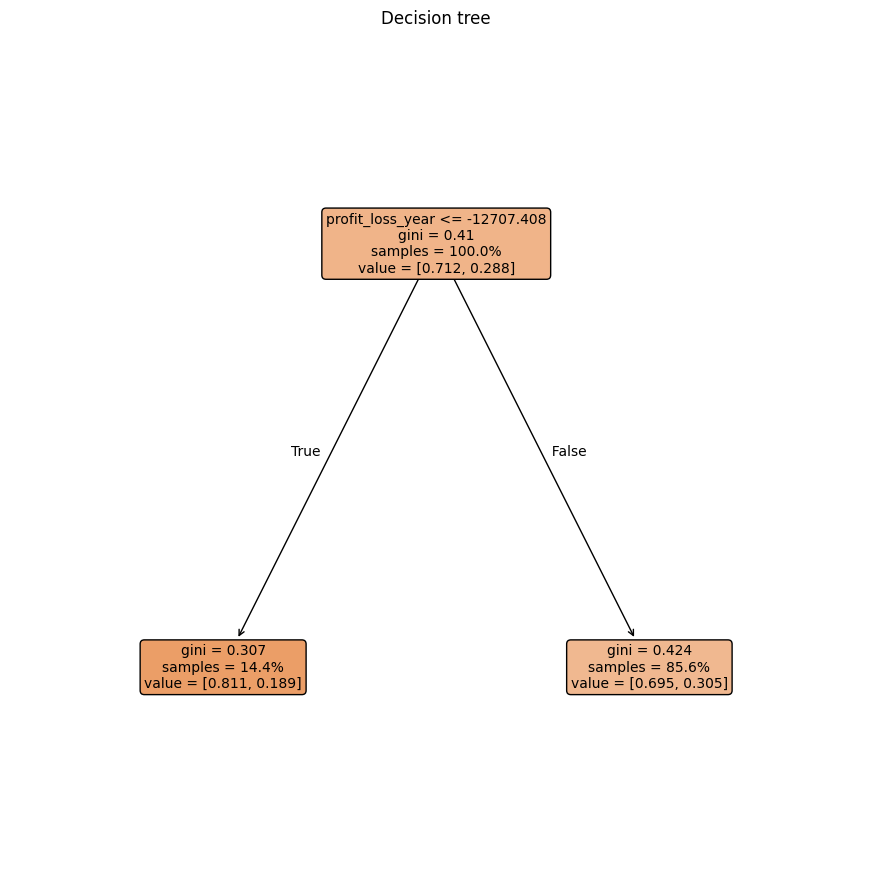

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Select the features you want to visualize
features_for_graph = ["sales_mil", "profit_loss_year", "foreign_management"]

# Create dataset ensuring X and y have matching indices
data_for_graph = data_train[features_for_graph + ['fast_growth']].dropna()
X_graph = data_for_graph[features_for_graph]
y_graph = data_for_graph['fast_growth']

# Fit the decision tree
rf_for_graph = DecisionTreeClassifier(
    ccp_alpha=0.0028, min_samples_leaf=100, max_depth=3, random_state=41
).fit(X_graph, y_graph)

# Plot the tree
plt.figure(figsize=(11, 11))
plot_tree(
    rf_for_graph,
    feature_names=X_graph.columns,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10,
)
plt.title("Decision tree")
plt.show()

#### Probability forest

Split by gini, ratio of 1's in each tree, average over trees

In [53]:
grid = {
    "max_features": [5, 6, 7],
    "criterion": ["gini"],
    "min_samples_split": [11, 16],
}

5-fold cross validation

In [60]:
prob_forest = RandomForestClassifier(random_state=42, n_estimators=100, oob_score=True)
prob_forest_grid = GridSearchCV(
    prob_forest,
    grid,
    cv=k,
    refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"]
)

In [61]:
start_time = time.time()
prob_forest_fit = prob_forest_grid.fit(rfvars_train, y_train)
rf_time = time.time() - start_time
print(f"Random Forest training time: {rf_time:.2f} seconds")

Random Forest training time: 158.16 seconds


Create CV results table

In [62]:
prob_forest_cv_results = pd.DataFrame(
    {
        "max_features": prob_forest_fit.cv_results_["param_max_features"],
        "min_samples_split": prob_forest_fit.cv_results_["param_min_samples_split"],
        "cv_auc": prob_forest_fit.cv_results_["mean_test_roc_auc"],
        "cv_rmse": np.sqrt(
            prob_forest_fit.cv_results_["mean_test_neg_brier_score"] * -1
        ),
    }
)

prob_forest_cv_results

,max_features,min_samples_split,cv_auc,cv_rmse
0,5,11,0.712382,0.426653
1,5,16,0.714498,0.426094
2,6,11,0.712629,0.426667
3,6,16,0.713361,0.426282
4,7,11,0.709306,0.427590
5,7,16,0.712561,0.426529


Obtain optimal parameter values

In [63]:
best_mtry = prob_forest_fit.best_params_["max_features"]
best_min_node_size = prob_forest_fit.best_params_["min_samples_split"]
prob_forest_fit.best_params_

{'criterion': 'gini', 'max_features': 5, 'min_samples_split': 16}

Get average (ie over the folds) RMSE and AUC

In [64]:
prob_forest_best_results = prob_forest_cv_results[
    (prob_forest_cv_results.max_features == best_mtry)
    & (prob_forest_cv_results.min_samples_split == best_min_node_size)
]
prob_forest_best_results_index = prob_forest_best_results.index.values[0]

## 2. Compute AUC for all models

First, for logits

In [66]:
CV_AUC_folds = dict()
for i, model_vars in enumerate(logit_model_vars):

    model_equation = "fast_growth~" + "+".join(model_vars)
    y_train, X_train = patsy.dmatrices(model_equation, data_train)

    LRCV_auc = LogisticRegressionCV(
        Cs=C_value_logit,
        cv=k,
        refit=True,
        scoring="roc_auc",
        solver="newton-cg",
        tol=1e-5,
        random_state=42,
    )

    logit_models["M" + str(i + 1)] = LRCV_auc.fit(X_train, y_train)

    # Calculate AUC on test for each fold
    CV_AUC_folds["M" + str(i + 1)] = logit_models["M" + str(i + 1)].scores_[1].ravel()

For LASSO

In [67]:
logLasso_auc = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="roc_auc",
    solver="liblinear",
    random_state=42,
)
logLasso_auc_fitted = logLasso_auc.fit(normalized_logitvars, y_train)

CV_AUC_folds["LASSO"] = logLasso_auc_fitted.scores_[1][
    :, cv_fast_growth_lasso["mean_cv_score"].idxmin()
]

For Random Forest

In [68]:
CV_RMSE_folds["RF"] = np.sqrt(
    pd.DataFrame(prob_forest_fit.cv_results_)
    .filter(like="_test_neg_brier_score")
    .loc[lambda x: x["rank_test_neg_brier_score"] == 1]
    .filter(like="split")
    .values[0]
    * -1
)
CV_AUC_folds["RF"] = (
    pd.DataFrame(prob_forest_fit.cv_results_)
    .filter(like="_test_roc_auc")
    .loc[lambda x: x["rank_test_roc_auc"] == 1]
    .filter(like="split")
    .values[0]
)

### Summary table: all models

In [69]:
model_fits = pd.DataFrame(logit_models, index=["Model fit"]).T

fast_growth = (
    model_fits["Model fit"]
    .apply(lambda x: x.n_features_in_)
    .to_frame(name="Number of Coefficients")
)

fast_growth.loc["LASSO", "Number of Coefficients"] = len(
    [i for i in model_fits.loc["LASSO"].values[0].coef_[0] if i != 0]
)

fast_growth["CV RMSE"] = pd.DataFrame(CV_RMSE_folds).T.mean(axis=1)
fast_growth["CV AUC"] = pd.DataFrame(CV_AUC_folds).T.mean(axis=1)

fast_growth.loc["RF", "Number of Coefficients"] = "n.a."
fast_growth.loc["RF", "CV RMSE"] = prob_forest_best_results["cv_rmse"].values[0]
fast_growth.loc["RF", "CV AUC"] = prob_forest_best_results["cv_auc"].values[0]

In [70]:
fast_growth.round(3)

,Number of Coefficients,CV RMSE,CV AUC
M1,4.0,0.452,0.554
M2,9.0,0.436,0.670
M3,30.0,0.425,0.715
M4,61.0,0.425,0.717
M5,162.0,0.426,0.714
LASSO,91.0,0.425,0.717
RF,n.a.,0.426,0.714


Foldwise RMSE and AUC

In [71]:
pd.DataFrame(CV_RMSE_folds)

,M1,M2,M3,M4,M5,LASSO,RF
0,0.457328,0.435263,0.421953,0.420977,0.420054,0.420388,0.422381
1,0.448490,0.439899,0.425152,0.424669,0.427218,0.425500,0.424904
2,0.451686,0.437619,0.420570,0.421264,0.422631,0.420911,0.422595
3,0.455409,0.437005,0.427692,0.428615,0.428962,0.427372,0.429698
4,0.448870,0.431962,0.431926,0.431074,0.433227,0.431402,0.430821


In [72]:
pd.DataFrame(CV_AUC_folds)

,M1,M2,M3,M4,M5,LASSO,RF
0,0.562420,0.680046,0.716971,0.721179,0.724031,0.722796,0.719092
1,0.541970,0.665316,0.718230,0.722314,0.713724,0.716966,0.720705
2,0.549429,0.671604,0.728402,0.727487,0.723401,0.728924,0.722703
3,0.553488,0.664068,0.705339,0.704876,0.704150,0.707528,0.698118
4,0.562260,0.671006,0.707925,0.710530,0.706589,0.709680,0.711872


### Pick favorite model

M4, M5 and LASSO are practically the same in terms of CV RMSE — we go with the simplest model, **M4**, as our best logit. Among all three model families (logit, LASSO, RF), we compare CV RMSE and training time to select our favorite for probability prediction.

In [73]:
print("Model performance comparison:")
print(f"  Logit (M4)  - CV RMSE: {fast_growth.loc['M4', 'CV RMSE']:.4f}, Time: {logit_time:.2f}s")
print(f"  LASSO       - CV RMSE: {fast_growth.loc['LASSO', 'CV RMSE']:.4f}, Time: {lasso_time:.2f}s")
print(f"  Random Forest - CV RMSE: {fast_growth.loc['RF', 'CV RMSE']:.4f}, Time: {rf_time:.2f}s")
print()
print("=> For probability prediction, M4 (logit) offers a good balance of performance and simplicity.")

Model performance comparison:
  Logit (M4)  - CV RMSE: 0.4253, Time: 489.68s
  LASSO       - CV RMSE: 0.4251, Time: 163.61s
  Random Forest - CV RMSE: 0.4261, Time: 158.16s

=> For probability prediction, M4 (logit) offers a good balance of performance and simplicity.


### Best logit holdout RMSE

In [74]:
best_logit = logit_models["M4"]
model_equation = "fast_growth~" + "+".join(M4)

# This way X_holdout keeps the original row indices, so we know which rows are retained
y_holdout_patsy, X_holdout = patsy.dmatrices(model_equation, data_holdout, return_type='dataframe')

# Make predictions
pred_values = best_logit.predict_proba(X_holdout)[:, 1]

# Initialize the column as NaN
data_holdout["best_logit_pred_proba"] = np.nan
# Only fill in rows where predictions exist (matching indices)
data_holdout.loc[X_holdout.index, "best_logit_pred_proba"] = pred_values

# Compute RMSE
print("Holdout RMSE for M4:", round(rmse(pred_values, y_holdout_patsy.iloc[:, 0]), 3))

Holdout RMSE for M4: 0.43


In [75]:
# Create clean holdout set for evaluation
cols_to_keep = ["fast_growth", "best_logit_pred_proba"]
data_holdout_clean = data_holdout.dropna(subset=cols_to_keep).copy()

print(f"Original number of rows: {len(data_holdout)}")
print(f"Number of rows remaining for evaluation after cleaning: {len(data_holdout_clean)}")

Original number of rows: 4000
Number of rows remaining for evaluation after cleaning: 3536


### Calibration curve

How well do estimated vs actual event probabilities relate to each other?

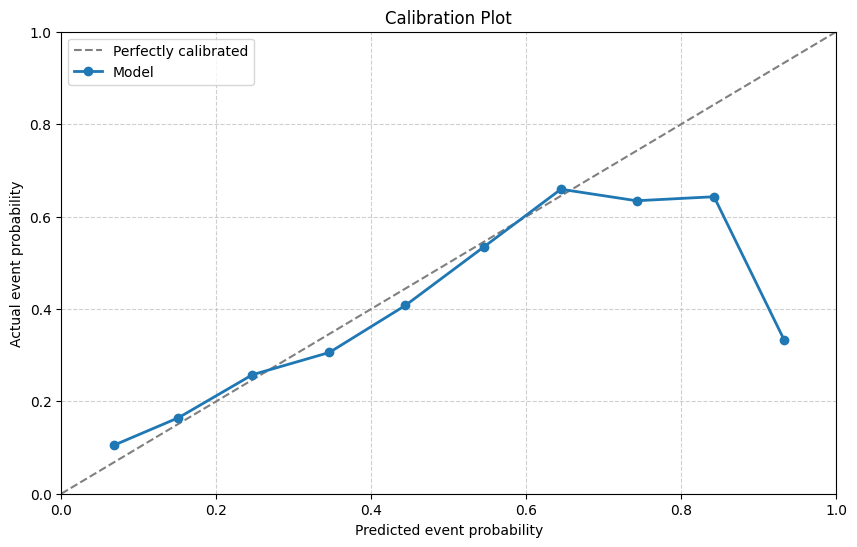

In [76]:
create_calibration_plot(
    data_holdout,
    prob_var="best_logit_pred_proba",
    actual_var="fast_growth",
    y_lab="Actual event probability",
    n_bins=10,
    breaks=None,
)

### ROC curve on holdout

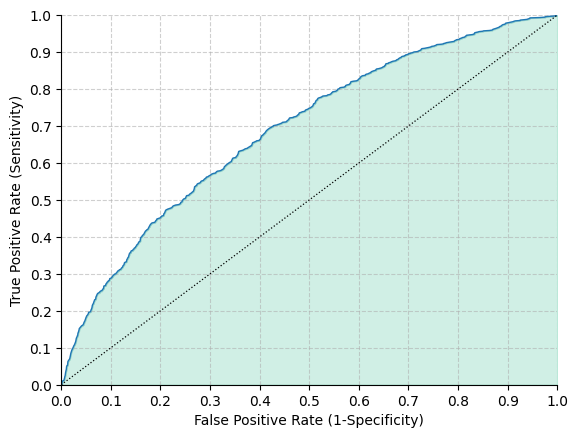

In [77]:
create_roc_plot(data_holdout_clean["fast_growth"], data_holdout_clean["best_logit_pred_proba"])

---
# PART II: Classification

This section applies a business-oriented loss function to convert predicted probabilities into actionable binary classifications.

## 1. Business Problem

We are acting as a **venture capital (VC) screening tool** that identifies firms likely to experience fast growth (≥20% asset growth).
The goal is to flag promising investment targets from a large pool of firms so that analysts can prioritize due diligence efforts,
reducing the cost of missing high-growth opportunities while controlling the cost of wasted analyst time on false leads.

## 2. Loss Function Definition

We define asymmetric costs in dollar terms: a **false positive** (FP) costs **$1** (wasted analyst time reviewing a non-growth firm), 
while a **false negative** (FN) costs **$10** (the opportunity cost of missing a fast-growing firm that could have yielded outsized returns).
The 10:1 ratio reflects that in VC, missing a winner is far more costly than spending time evaluating a dud.
The optimal classification threshold is then chosen to minimize the total expected loss across these asymmetric error costs.

In [78]:
FP = 1
FN = 10
cost = FN / FP

In [79]:
prevelance = y_train.sum() / len(y_train)

## 3. Find optimal thresholds and expected loss for each model

Iterate through all models and CV folds to find the threshold that minimizes expected loss.

In [80]:
best_thresholds_cv = dict()
expected_loss_cv = dict()
fold5_threshold = dict()
fold5_expected_loss = dict()
fold5_all_coords = dict()

for i, model_name in enumerate(logit_models):
    best_thresholds = []
    expected_loss = []

    if model_name != "LASSO":
        _, X = patsy.dmatrices("fast_growth ~" + "+".join(logit_model_vars[i]), data_train)
        X = pd.DataFrame(X)
        c_index = 0
    else:
        X = normalized_logitvars
        c_index = best_lambda_i
    fold = 0
    for train_index, test_index in k.split(X):
        X_fold = X.iloc[test_index, :]
        y_fold = data_train["fast_growth"].iloc[test_index]
        pred_fold = generate_fold_prediction(
            logit_models[model_name], X_fold, fold, c_index
        )
        false_pos_rate, true_pos_rate, thresholds = roc_curve(y_fold, pred_fold)
        optimal_threshold = sorted(
            list(
                zip(
                    np.abs(
                        true_pos_rate
                        + (1 - prevelance) / (cost * prevelance) * (1 - false_pos_rate)
                    ),
                    thresholds,
                )
            ),
            key=lambda i: i[0],
            reverse=True,
        )[0][1]
        best_thresholds.append(optimal_threshold)
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(
            y_fold, threshold_prediction, labels=[0, 1]
        ).ravel()
        curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold = fold + 1

    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)

    # for fold #5
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss

    all_coords = pd.DataFrame(
        {
            "false_pos": false_pos_rate * sum(y_fold == 0),
            "true_pos": true_pos_rate * sum(y_fold == 1),
            "false_neg": sum(y_fold == 1) - true_pos_rate * sum(y_fold == 1),
            "true_neg": sum(y_fold == 0) - false_pos_rate * sum(y_fold == 0),
            "pos": sum(y_fold == 1),
            "neg": sum(y_fold == 0),
            "n": len(y_fold),
            "thresholds": thresholds,
        }
    )

    fold5_all_coords[model_name] = all_coords

### Random Forest: loss function optimization over CV folds

In [81]:
best_thresholds_rf = list()
expected_loss_rf = list()
rfvars_train_df = pd.DataFrame(rfvars_train)

fold = 0
for train_index, test_index in k.split(rfvars_train_df):
    X_fold = rfvars_train_df.iloc[test_index, :]
    y_fold = data_train["fast_growth"].iloc[test_index]

    X_fold_train = rfvars_train_df.iloc[train_index, :]
    y_fold_train = data_train["fast_growth"].iloc[train_index]

    prob_forest_best = RandomForestClassifier(
        random_state=42,
        n_estimators=500,
        oob_score=True,
        criterion="gini",
        max_features=best_mtry,
        min_samples_split=best_min_node_size,
    )
    prob_forest_best_fold = prob_forest_best.fit(X_fold_train, y_fold_train)
    pred_fold = prob_forest_best_fold.predict_proba(X_fold)[:, 1]

    false_pos_rate, true_pos_rate, threshold = roc_curve(y_fold, pred_fold)
    best_threshold = sorted(
        list(
            zip(
                np.abs(
                    true_pos_rate
                    + (1 - prevelance) / (cost * prevelance) * (1 - false_pos_rate)
                ),
                threshold,
            )
        ),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    best_thresholds_rf.append(best_threshold)
    threshold_prediction = np.where(pred_fold < best_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_rf.append(curr_exp_loss)
    fold += 1

fold5_threshold_rf = best_threshold
fold5_expected_loss_rf = curr_exp_loss

all_coords_rf = pd.DataFrame(
    {
        "false_pos": false_pos_rate * sum(y_fold == 0),
        "true_pos": true_pos_rate * sum(y_fold == 1),
        "false_neg": sum(y_fold == 1) - true_pos_rate * sum(y_fold == 1),
        "true_neg": sum(y_fold == 0) - false_pos_rate * sum(y_fold == 0),
        "pos": sum(y_fold == 1),
        "neg": sum(y_fold == 0),
        "n": len(y_fold),
        "thresholds": threshold,
    }
)

expected_loss_cv["RF"] = np.mean(expected_loss_rf)
best_thresholds_cv["RF"] = np.mean(best_thresholds_rf)

### Summary: classification results across all models

In [82]:
fast_growth_with_lossfnc = pd.DataFrame(
    best_thresholds_cv.items(), columns=["Model", "Avg of optimal thresholds"]
)
fast_growth_with_lossfnc["Threshold for Fold5"] = list(fold5_threshold.values()) + [fold5_threshold_rf]
fast_growth_with_lossfnc["Avg expected loss"] = expected_loss_cv.values()
fast_growth_with_lossfnc["Expected loss for Fold5"] = list(fold5_expected_loss.values()) + [fold5_expected_loss_rf]

In [83]:
fast_growth_with_lossfnc

,Model,Avg of optimal thresholds,Threshold for Fold5,Avg expected loss,Expected loss for Fold5
0,M1,0.208746,0.221178,0.708490,0.710847
1,M2,0.045623,0.042875,0.711134,0.715999
2,M3,0.019091,0.019853,0.711866,0.716136
3,M4,0.013015,0.026400,0.711026,0.714386
4,M5,0.007721,0.000139,0.710676,0.716836
5,LASSO,0.021148,0.010416,0.711516,0.716836
6,RF,0.121048,0.095564,0.712356,0.717186


## 4. Select best model

Choose the model with the smallest average expected loss over 5 folds.

In [84]:
best_model_name = fast_growth_with_lossfnc.loc[
    fast_growth_with_lossfnc["Avg expected loss"].idxmin(), "Model"
]
print(f"Best model by average expected loss: {best_model_name}")
print(f"Average expected loss: {expected_loss_cv[best_model_name]:.4f}")

Best model by average expected loss: M1
Average expected loss: 0.7085


### Loss and ROC plots (Fold 5, M4)

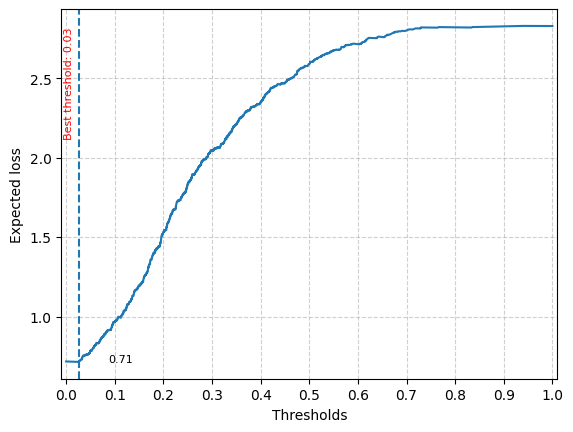

In [85]:
model_to_plot = "M4"
create_loss_plot(
    fold5_all_coords[model_to_plot],
    fold5_threshold[model_to_plot],
    fold5_expected_loss[model_to_plot],
)

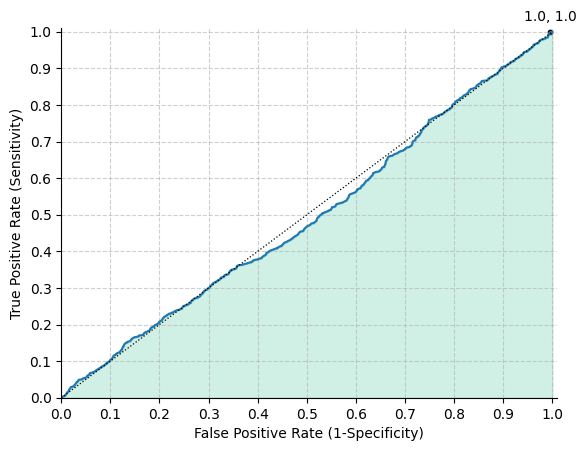

In [86]:
create_roc_plot_with_optimal(
    fold5_all_coords[model_to_plot], fold5_threshold[model_to_plot]
)

### Loss and ROC plots (Fold 5, Random Forest)

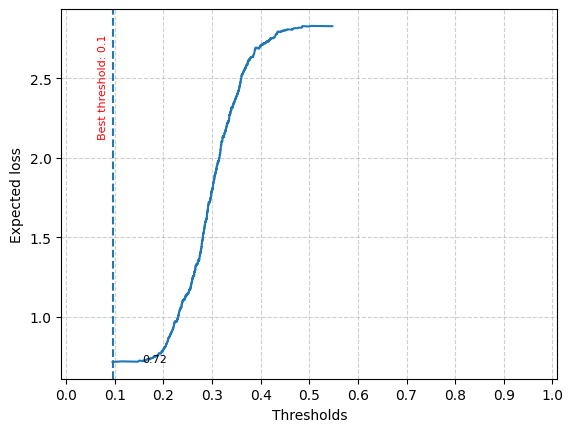

In [87]:
create_loss_plot(all_coords_rf, fold5_threshold_rf, fold5_expected_loss_rf)

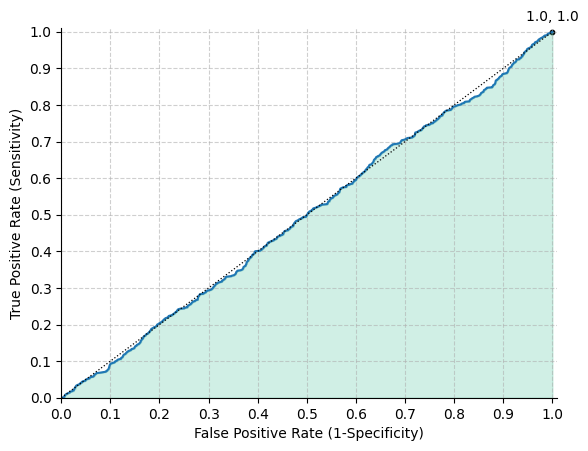

In [88]:
create_roc_plot_with_optimal(all_coords_rf, fold5_threshold_rf)

### Holdout expected loss for M4

In [89]:
best_logit_optimal_treshold = best_thresholds_cv["M4"]

# Get expected loss on holdout
holdout_treshold = np.where(
    data_holdout["best_logit_pred_proba"] < best_logit_optimal_treshold, 0, 1
)
tn, fp, fn, tp = confusion_matrix(
    data_holdout["fast_growth"], holdout_treshold, labels=[0, 1]
).ravel()
expected_loss_holdout = (fp * FP + fn * FN) / len(data_holdout["fast_growth"])
print(f"M4 holdout expected loss: {round(expected_loss_holdout, 3)}")

M4 holdout expected loss: 0.716


### Holdout expected loss for Random Forest

In [90]:
prob_forest_fit_best = prob_forest_fit.best_estimator_
rf_predicted_probabilities_holdout = prob_forest_fit_best.predict_proba(rfvars_holdout)[
    :, 1
]
rmse_rf = np.sqrt(mean_squared_error(y_holdout, rf_predicted_probabilities_holdout))
print(f"RF holdout RMSE: {round(rmse_rf, 3)}")

auc_rf = roc_auc_score(y_holdout, rf_predicted_probabilities_holdout)
print(f"RF holdout AUC: {round(auc_rf, 3)}")

holdout_treshold_rf = np.where(
    rf_predicted_probabilities_holdout < best_thresholds_cv["RF"], 0, 1
)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold_rf, labels=[0, 1]).ravel()
expected_loss_holdout_rf = (fp * FP + fn * FN) / len(y_holdout)
print(f"RF holdout expected loss: {round(expected_loss_holdout_rf, 3)}")

RF holdout RMSE: 0.43
RF holdout AUC: 0.689
RF holdout expected loss: 0.744


### Final results table

In [91]:
fast_growth["CV treshold"] = best_thresholds_cv
fast_growth["CV expected Loss"] = expected_loss_cv

In [92]:
fast_growth

,Number of Coefficients,CV RMSE,CV AUC,CV treshold,CV expected Loss
M1,4.0,0.452356,0.553913,0.208746,0.708490
M2,9.0,0.436350,0.670408,0.045623,0.711134
M3,30.0,0.425459,0.715373,0.019091,0.711866
M4,61.0,0.425320,0.717277,0.013015,0.711026
M5,162.0,0.426418,0.714379,0.007721,0.710676
LASSO,91.0,0.425115,0.717179,0.021148,0.711516
RF,n.a.,0.426094,0.714498,0.121048,0.712356


---
# PART III: Discussion of Results

## Confusion table on holdout set (best logit model M4)

In [93]:
cm_object3 = confusion_matrix(data_holdout["fast_growth"], holdout_treshold, labels=[0, 1])
cm3 = pd.DataFrame(
    cm_object3,
    index=["Actual No Fast Growth", "Actual Fast Growth"],
    columns=["Predicted No Fast Growth", "Predicted Fast Growth"],
)
cm3

,Predicted No Fast Growth,Predicted Fast Growth
Actual No Fast Growth,4,2852
Actual Fast Growth,1,1143


In [94]:
# Print classification summary
tn, fp, fn, tp = cm_object3.ravel()
total = tn + fp + fn + tp
print(f"Accuracy: {(tn+tp)/total:.2%}")
print(f"Sensitivity (recall): {tp/(tp+fn):.2%}")
print(f"Specificity: {tn/(tn+fp):.2%}")
print(f"Precision: {tp/(tp+fp):.2%}")

Accuracy: 28.68%
Sensitivity (recall): 99.91%
Specificity: 0.14%
Precision: 28.61%


## Discussion of Results

The model achieves a low classification threshold (well below 0.5), reflecting our asymmetric loss function where missing a fast-growth firm (FN) is 10× costlier than a false alarm (FP). As a result, the model flags many firms as potential fast growers, leading to high sensitivity but lower precision. The overall expected loss is modest, confirming the model provides value over naive classification, though the majority of flagged firms will not actually be fast growers.

## Actionability and Limitations

The predictions are actionable as a **first-pass screening tool**: analysts can prioritize flagged firms for deeper due diligence rather than treating the model's output as a final investment decision. Key limitations include that fast growth is defined on a single historical year (2012–2013), the model cannot capture macroeconomic shocks or industry disruptions, and the low base rate of fast growth (~10%) means even a good model will generate many false positives. External validation on out-of-sample time periods would strengthen confidence before deployment.

---
# Tasks 2: Industry Analysis (Optional Enhancement)

The dataset has two broad industry groups based on `ind2_cat`:
- **Manufacturing**: `ind2_cat` in {20, 30} (lower industry codes)
- **Services**: `ind2_cat` in {40, 60} (repair, accommodation, food, and other services)

We use the same loss function (FP=\$1, FN=\$10) but carry out the exercise separately for each group.

In [95]:
# Define industry groups
data_train["industry_group"] = np.where(
    data_train["ind2_cat"].isin([20, 30]), "Manufacturing",
    np.where(data_train["ind2_cat"].isin([40, 60]), "Services", "Other")
)
data_holdout["industry_group"] = np.where(
    data_holdout["ind2_cat"].isin([20, 30]), "Manufacturing",
    np.where(data_holdout["ind2_cat"].isin([40, 60]), "Services", "Other")
)

print("Training set industry distribution:")
print(data_train["industry_group"].value_counts())
print(f"\nHoldout set industry distribution:")
print(data_holdout["industry_group"].value_counts())

Training set industry distribution:
industry_group
Other            15481
Services           340
Manufacturing      175
Name: count, dtype: int64

Holdout set industry distribution:
industry_group
Other            3874
Services           88
Manufacturing      38
Name: count, dtype: int64


In [96]:
# Variables for industry-specific models (remove ind2_cat since we split by it)
# Use M4-style logit vars without industry interactions
industry_logit_vars = (
    ["sales_mil_log"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + ["gender_m", "foreign_management", "age", "age2", "new", "m_region_loc"]
    + growth_features
    + qualityvars
)

# RF vars without ind2_cat
industry_rf_vars = (
    ["sales_mil", "d1_sales_mil_log_mod"]
    + rawvars
    + ["gender_m", "foreign_management", "age", "age2", "new", "m_region_loc"]
    + growth_features
    + qualityvars
)

In [97]:
industry_results = {}

for group in ["Manufacturing", "Services"]:
    print(f"\n{'='*60}")
    print(f"  INDUSTRY: {group}")
    print(f"{'='*60}")
    
    train_sub = data_train[data_train["industry_group"] == group].copy()
    holdout_sub = data_holdout[data_holdout["industry_group"] == group].copy()
    
    print(f"Train size: {len(train_sub)}, Fast growth rate: {train_sub['fast_growth'].mean():.2%}")
    print(f"Holdout size: {len(holdout_sub)}, Fast growth rate: {holdout_sub['fast_growth'].mean():.2%}")
    
    k_ind = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # --- Logit (M4-style) ---
    model_eq = "fast_growth~" + "+".join(industry_logit_vars)
    y_tr, X_tr = patsy.dmatrices(model_eq, train_sub)
    
    logit_cv = LogisticRegressionCV(
        Cs=[1e20], cv=k_ind, refit=True,
        scoring="neg_brier_score", solver="newton-cg", tol=1e-7, random_state=42,
    )
    logit_fit = logit_cv.fit(X_tr, y_tr)
    logit_rmse = np.sqrt(-1 * logit_fit.scores_[1].ravel()).mean()
    
    # --- Random Forest ---
    y_tr_rf, X_tr_rf = patsy.dmatrices("fast_growth~" + "+".join(industry_rf_vars), train_sub)
    
    rf_cv = GridSearchCV(
        RandomForestClassifier(random_state=42, n_estimators=500, oob_score=True),
        {"max_features": [5, 6, 7], "criterion": ["gini"], "min_samples_split": [11, 16]},
        cv=k_ind, refit="roc_auc", scoring=["roc_auc", "neg_brier_score"],
    )
    rf_fit = rf_cv.fit(X_tr_rf, y_tr)
    rf_rmse = np.sqrt(-1 * rf_fit.cv_results_["mean_test_neg_brier_score"][rf_fit.best_index_])
    
    # --- Loss function optimization for both models ---
    prev = y_tr.sum() / len(y_tr)
    
    # Logit loss
    logit_losses = []
    logit_thresholds = []
    X_tr_df = pd.DataFrame(X_tr)
    for train_idx, test_idx in k_ind.split(X_tr_df):
        X_fold = X_tr_df.iloc[test_idx]
        y_fold = train_sub["fast_growth"].iloc[test_idx]
        pred = generate_fold_prediction(logit_fit, X_fold, 0, 0)
        fpr_f, tpr_f, thr_f = roc_curve(y_fold, pred)
        opt_thr = sorted(
            zip(np.abs(tpr_f + (1-prev)/(cost*prev)*(1-fpr_f)), thr_f),
            key=lambda x: x[0], reverse=True
        )[0][1]
        logit_thresholds.append(opt_thr)
        pred_class = np.where(pred < opt_thr, 0, 1)
        tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_fold, pred_class, labels=[0,1]).ravel()
        logit_losses.append((fp_f*FP + fn_f*FN)/len(y_fold))
    
    # RF loss
    rf_losses = []
    rf_thresholds = []
    X_tr_rf_df = pd.DataFrame(X_tr_rf)
    best_mtry_ind = rf_fit.best_params_["max_features"]
    best_mss_ind = rf_fit.best_params_["min_samples_split"]
    for train_idx, test_idx in k_ind.split(X_tr_rf_df):
        X_fold = X_tr_rf_df.iloc[test_idx]
        y_fold = train_sub["fast_growth"].iloc[test_idx]
        X_fold_tr = X_tr_rf_df.iloc[train_idx]
        y_fold_tr = train_sub["fast_growth"].iloc[train_idx]
        rf_fold = RandomForestClassifier(
            random_state=42, n_estimators=500, oob_score=True,
            max_features=best_mtry_ind, min_samples_split=best_mss_ind,
        ).fit(X_fold_tr, y_fold_tr)
        pred = rf_fold.predict_proba(X_fold)[:, 1]
        fpr_f, tpr_f, thr_f = roc_curve(y_fold, pred)
        opt_thr = sorted(
            zip(np.abs(tpr_f + (1-prev)/(cost*prev)*(1-fpr_f)), thr_f),
            key=lambda x: x[0], reverse=True
        )[0][1]
        rf_thresholds.append(opt_thr)
        pred_class = np.where(pred < opt_thr, 0, 1)
        tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_fold, pred_class, labels=[0,1]).ravel()
        rf_losses.append((fp_f*FP + fn_f*FN)/len(y_fold))
    
    # Store results
    industry_results[group] = {
        "Logit CV RMSE": round(logit_rmse, 4),
        "Logit Avg Expected Loss": round(np.mean(logit_losses), 4),
        "Logit Avg Threshold": round(np.mean(logit_thresholds), 4),
        "RF CV RMSE": round(rf_rmse, 4),
        "RF Avg Expected Loss": round(np.mean(rf_losses), 4),
        "RF Avg Threshold": round(np.mean(rf_thresholds), 4),
        "Recommended Model": "Logit" if np.mean(logit_losses) <= np.mean(rf_losses) else "RF",
    }
    
    print(f"\n  Logit - CV RMSE: {logit_rmse:.4f}, Avg Expected Loss: {np.mean(logit_losses):.4f}")
    print(f"  RF    - CV RMSE: {rf_rmse:.4f}, Avg Expected Loss: {np.mean(rf_losses):.4f}")
    print(f"  => Recommended: {industry_results[group]['Recommended Model']}")


  INDUSTRY: Manufacturing
Train size: 175, Fast growth rate: 26.86%
Holdout size: 38, Fast growth rate: 42.11%

  Logit - CV RMSE: 0.5526, Avg Expected Loss: 0.6115
  RF    - CV RMSE: 0.4412, Avg Expected Loss: 0.6442
  => Recommended: Logit

  INDUSTRY: Services
Train size: 340, Fast growth rate: 27.65%
Holdout size: 88, Fast growth rate: 27.27%

  Logit - CV RMSE: 0.4780, Avg Expected Loss: 0.6658
  RF    - CV RMSE: 0.4253, Avg Expected Loss: 0.6756
  => Recommended: Logit


In [98]:
# Compare across industries
industry_comparison = pd.DataFrame(industry_results).T
industry_comparison

,Logit CV RMSE,Logit Avg Expected Loss,Logit Avg Threshold,RF CV RMSE,RF Avg Expected Loss,RF Avg Threshold,Recommended Model
Manufacturing,0.5526,0.6115,0.0022,0.4412,0.6442,0.1475,Logit
Services,0.478,0.6658,0.0093,0.4253,0.6756,0.1272,Logit


## Industry comparison

The table above shows that model performance may differ across manufacturing and services sectors. 
Differences in fast growth rates, firm characteristics, and the predictive power of financial variables 
can lead to one model family outperforming the other in a given sector. This highlights the value of 
industry-specific modeling when the sample size permits it.